In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('placement.csv')
df.head()


,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


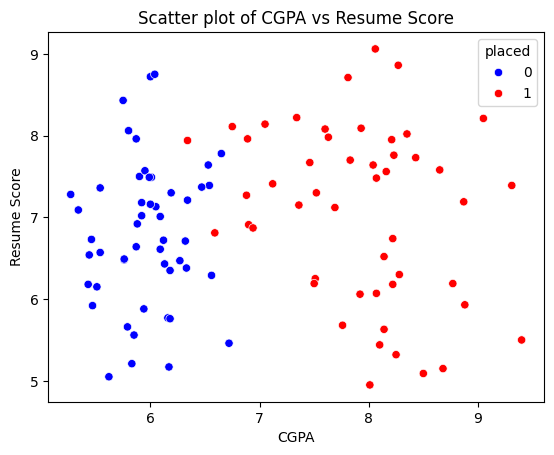

In [5]:
# scatter plot
sns.scatterplot(x='cgpa', y='resume_score', hue='placed', palette={1: 'red', 0: 'blue'}, data=df)
plt.title('Scatter plot of CGPA vs Resume Score')
plt.xlabel('CGPA')
plt.ylabel('Resume Score')
plt.show()

### now apply perceptron

In [6]:
from sklearn.linear_model import Perceptron

In [9]:
# fit the seperator line
x=df[['cgpa', 'resume_score']].values
x

array([[8.14, 6.52],
       [6.17, 5.17],
       [8.27, 8.86],
       [6.88, 7.27],
       [7.52, 7.3 ],
       [8.77, 6.19],
       [5.34, 7.09],
       [6.56, 6.29],
       [6.32, 6.71],
       [7.69, 7.12],
       [6.18, 6.35],
       [5.44, 6.54],
       [6.09, 7.01],
       [8.5 , 5.09],
       [7.51, 6.25],
       [8.88, 5.93],
       [8.04, 7.64],
       [7.81, 8.71],
       [5.94, 5.88],
       [6.75, 8.11],
       [5.8 , 8.06],
       [6.53, 7.64],
       [6.16, 5.77],
       [6.05, 7.13],
       [8.22, 6.18],
       [7.76, 5.68],
       [6.27, 6.47],
       [5.51, 6.15],
       [7.46, 7.67],
       [6.19, 7.3 ],
       [7.36, 7.15],
       [5.92, 7.02],
       [5.87, 7.96],
       [8.43, 7.73],
       [8.87, 7.19],
       [8.07, 7.48],
       [8.16, 7.56],
       [9.05, 8.21],
       [6.  , 8.72],
       [7.5 , 6.19],
       [8.25, 5.32],
       [8.68, 5.15],
       [6.9 , 6.91],
       [8.21, 7.95],
       [5.47, 5.92],
       [8.1 , 5.44],
       [5.83, 5.21],
       [7.05,

In [10]:
y=df['placed'].values
y

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [11]:
model=Perceptron()
model.fit(x, y)


Perceptron()

In [12]:
model.coef_


array([[ 40.26, -36.  ]])

In [13]:
model.intercept_

array([-25.])

In [17]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

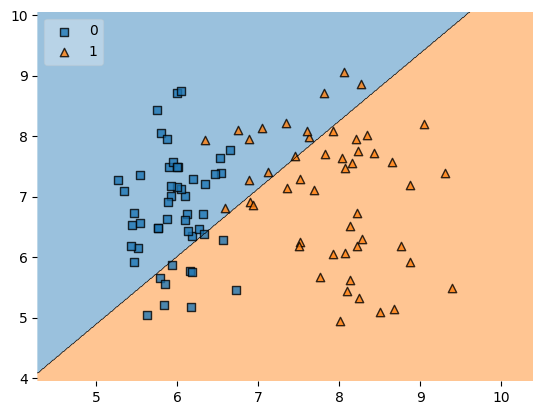

In [18]:
plot_decision_regions(x, y, clf=model, legend=2)

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split data first
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the scaler and logistic regression
scaler = StandardScaler()
logistic_model = LogisticRegression()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data (only transform, not fit)
X_test_scaled = scaler.transform(X_test)

# Fit the logistic regression model
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [25]:
# Predict on the test set
y_pred = logistic_model.predict(X_test_scaled)
# Check the accuracy of the model
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
r2=r2_score(y_test, y_pred)
mean_squared_error=mean_squared_error(y_test, y_pred)
print(f"R2 score: {r2}")
print(f"Mean Squared Error: {mean_squared_error}")


Accuracy: 100.00%
R2 score: 1.0
Mean Squared Error: 0.0


In [26]:
# let me take a new student and predict if he will be placed or not
new_student = np.array([[8.5, 85]])
new_student_scaled = scaler.transform(new_student)
prediction = logistic_model.predict(new_student_scaled)
print(f"Prediction for new student (1: Placed, 0: Not Placed): {prediction[0]}")

Prediction for new student (1: Placed, 0: Not Placed): 1
